**Merging Relevant features on BL**

The main purpose of the script is to preprocess the PPMI dataset for further downstream ML pipeline, we identified relevant features like clinical scores, MRI and genotype all in seperate files in LONL PPPMI site, we processes and merged this data into a single tabular data with cohort definition.

As the dataset is originally longitudinal we reduced our proceesing to the Baseline data. Preliminarily we viewed the missingness before and after merging features and the main output is a tabular csv file **"baseline_df3.csv"**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("full_pd_dataset_with_duplicates_resolved (1).csv")

In [ ]:
df.head()

,PATNO,EVENT_ID,NP1RTOT,NP2PTOT,NP3TOT,NP1DDS,NP1APAT,NP2WALK,NP2FREZ,NP3BRADY,...,superiorparietal_avg,caudalanteriorcingulate_avg,posteriorcingulate_avg,entorhinal_avg,parahippocampal_avg,insula_avg,supramarginal_avg,APOE,COHORT_DEFINITION,AGE_AT_VISIT
0,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,69.1
1,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,80.5
2,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,81.4
3,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,69.1
4,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,69.4


In [ ]:
event_counts = df['EVENT_ID'].value_counts().reset_index()
event_counts.columns = ['EVENT_ID', 'Count']
print(event_counts)

   EVENT_ID  Count
0        BL  37367
1       V04  37199
2       V06  32547
3       V08  28143
4       V10  26173
5       V12  25066
6       V05  22568
7       V02  21704
8       V14  20685
9       V13  19708
10      V15  15714
11       SC  15208
12      V07  14503
13      V17  13846
14      V16  12757
15      V09  12185
16      V18  11257
17      V19   9565
18      V11   9478
19      V01   8920
20      R17   8679
21      V03   8107
22      R18   7893
23      R16   7777
24      R13   6668
25      R12   6218
26      R15   5862
27      R01   5805
28      R19   5471
29      R14   5282
30      V20   4815
31      R10   4713
32      R06   4536
33       ST   3920
34      R08   3521
35      R04   2811
36      R20   1577
37      V21    930
38      U01    105
39       PW     71
40      RS1     54


In [ ]:
event_counts = df['EVENT_ID'].value_counts().reset_index()
event_counts.columns = ['EVENT_ID', 'Count']
print(event_counts)

   EVENT_ID  Count
0        BL  37367
1       V04  37199
2       V06  32547
3       V08  28143
4       V10  26173
5       V12  25066
6       V05  22568
7       V02  21704
8       V14  20685
9       V13  19708
10      V15  15714
11       SC  15208
12      V07  14503
13      V17  13846
14      V16  12757
15      V09  12185
16      V18  11257
17      V19   9565
18      V11   9478
19      V01   8920
20      R17   8679
21      V03   8107
22      R18   7893
23      R16   7777
24      R13   6668
25      R12   6218
26      R15   5862
27      R01   5805
28      R19   5471
29      R14   5282
30      V20   4815
31      R10   4713
32      R06   4536
33       ST   3920
34      R08   3521
35      R04   2811
36      R20   1577
37      V21    930
38      U01    105
39       PW     71
40      RS1     54


In [ ]:
# Keep only rows where EVENT_ID == 'BL'
baseline_df = df[df['EVENT_ID'] == 'BL'].copy()

# Verify
print(f"Total baseline records: {len(baseline_df)}")
print(baseline_df['EVENT_ID'].value_counts())

Total baseline records: 37367
EVENT_ID
BL    37367
Name: count, dtype: int64


In [ ]:
baseline_df.head()

,PATNO,EVENT_ID,NP1RTOT,NP2PTOT,NP3TOT,NP1DDS,NP1APAT,NP2WALK,NP2FREZ,NP3BRADY,...,superiorparietal_avg,caudalanteriorcingulate_avg,posteriorcingulate_avg,entorhinal_avg,parahippocampal_avg,insula_avg,supramarginal_avg,APOE,COHORT_DEFINITION,AGE_AT_VISIT
0,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,69.1
1,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,80.5
2,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,81.4
3,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,69.1
4,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,5776.5,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,69.4


In [ ]:
baseline_df.shape

(37367, 37)

In [ ]:
baseline_df.columns

Index(['PATNO', 'EVENT_ID', 'NP1RTOT', 'NP2PTOT', 'NP3TOT', 'NP1DDS',
       'NP1APAT', 'NP2WALK', 'NP2FREZ', 'NP3BRADY', 'NP3PSTBL', 'NP3RIGN',
       'NP3GAIT', 'MCATOT', 'hippocampus_norm', 'amygdala_norm',
       'thalamus_norm', 'caudate_norm', 'putamen_norm', 'accumbens_norm',
       'lateral_ventricle_norm', '3rd_ventricle_norm', '4th_ventricle_norm',
       'brainsegvol_norm', 'superiorfrontal_avg', 'caudalmiddlefrontal_avg',
       'rostralmiddlefrontal_avg', 'superiorparietal_avg',
       'caudalanteriorcingulate_avg', 'posteriorcingulate_avg',
       'entorhinal_avg', 'parahippocampal_avg', 'insula_avg',
       'supramarginal_avg', 'APOE', 'COHORT_DEFINITION', 'AGE_AT_VISIT'],
      dtype='object')

In [ ]:
# Calculate missing values per column
missing_stats = baseline_df.isnull().sum().sort_values(ascending=False)
missing_stats = missing_stats[missing_stats > 0]  # Show only columns with missing data

# Convert to percentage
missing_percent = (baseline_df.isnull().mean() * 100).round(2)
missing_percent = missing_percent[missing_percent > 0]  # Filter columns with >0% missing

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing_Count': missing_stats,
    'Missing_Percent (%)': missing_percent
})

print("Missing Data Summary:")
print(missing_summary)

Missing Data Summary:
                             Missing_Count  Missing_Percent (%)
3rd_ventricle_norm                   15285                40.91
4th_ventricle_norm                   15285                40.91
APOE                                  1506                 4.03
MCATOT                                 175                 0.47
NP1RTOT                                110                 0.29
NP2FREZ                                 61                 0.16
NP2PTOT                                 63                 0.17
NP2WALK                                 61                 0.16
NP3BRADY                               165                 0.44
NP3GAIT                                165                 0.44
NP3PSTBL                               167                 0.45
NP3RIGN                                165                 0.44
NP3TOT                                 394                 1.05
accumbens_norm                       15285                40.91
amygdala_norm     

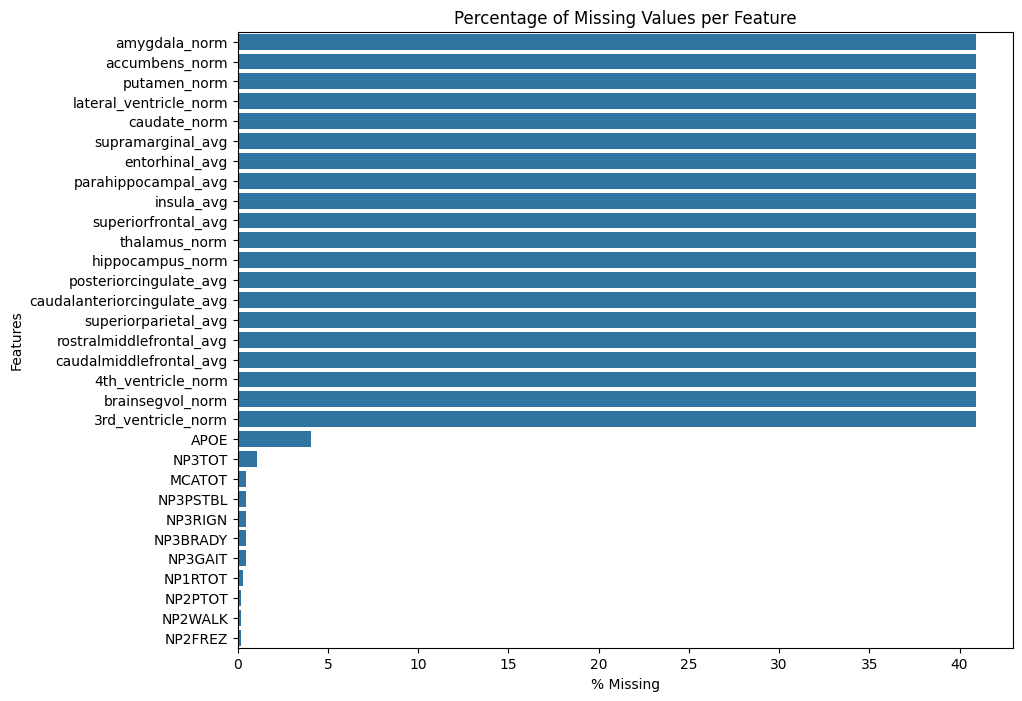

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sort by % missing
missing_df = baseline_df.isnull().mean().sort_values(ascending=False) * 100
missing_df = missing_df[missing_df > 0]

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(y=missing_df.index, x=missing_df.values)
plt.title("Percentage of Missing Values per Feature")
plt.xlabel("% Missing")
plt.ylabel("Features")
plt.show()


In [ ]:
# Save the full dataset
baseline_df.to_csv("baselinePPMI1.csv", index=False)

In [ ]:
baseline_df = baseline_df.drop(columns=['AGE_AT_VISIT'])

In [ ]:
print("Columns after dropping 'Age_at_visit':", baseline_df.columns.tolist())

Columns after dropping 'Age_at_visit': ['PATNO', 'EVENT_ID', 'NP1RTOT', 'NP2PTOT', 'NP3TOT', 'NP1DDS', 'NP1APAT', 'NP2WALK', 'NP2FREZ', 'NP3BRADY', 'NP3PSTBL', 'NP3RIGN', 'NP3GAIT', 'MCATOT', 'hippocampus_norm', 'amygdala_norm', 'thalamus_norm', 'caudate_norm', 'putamen_norm', 'accumbens_norm', 'lateral_ventricle_norm', '3rd_ventricle_norm', '4th_ventricle_norm', 'brainsegvol_norm', 'superiorfrontal_avg', 'caudalmiddlefrontal_avg', 'rostralmiddlefrontal_avg', 'superiorparietal_avg', 'caudalanteriorcingulate_avg', 'posteriorcingulate_avg', 'entorhinal_avg', 'parahippocampal_avg', 'insula_avg', 'supramarginal_avg', 'APOE', 'COHORT_DEFINITION']


In [ ]:
baseline_df.shape

(37367, 36)

In [ ]:
baseline_df1 = baseline_df.drop_duplicates()


In [ ]:
baseline_df1.shape

(4347, 36)

In [ ]:
baseline_df1.to_csv("baseline_df1.csv", index=False)

Preprocess the age data and merge to the rest of the dataset

In [ ]:
Age_df = pd.read_csv("Age_at_visit_16May2025.csv")

In [ ]:
Age_df.head()

,PATNO,EVENT_ID,AGE_AT_VISIT
0,3000,BL,69.1
1,3000,R17,80.5
2,3000,R18,81.4
3,3000,SC,69.1
4,3000,V01,69.4


In [ ]:
Age_df.shape

(35906, 3)

In [ ]:
#filter by BL

Age_df1 = Age_df[Age_df['EVENT_ID'] == 'BL'].copy()

In [ ]:
Age_df1.shape

(4248, 3)

In [ ]:
baseline_df2 = pd.merge(
    baseline_df1,
    Age_df1,
    on=["PATNO",],
    how="inner"
)

In [ ]:
baseline_df2.shape

(4391, 38)

In [ ]:
baseline_df2.head()

,PATNO,EVENT_ID_x,NP1RTOT,NP2PTOT,NP3TOT,NP1DDS,NP1APAT,NP2WALK,NP2FREZ,NP3BRADY,...,caudalanteriorcingulate_avg,posteriorcingulate_avg,entorhinal_avg,parahippocampal_avg,insula_avg,supramarginal_avg,APOE,COHORT_DEFINITION,EVENT_ID_y,AGE_AT_VISIT
0,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,BL,69.1
1,3001,BL,0.0,2.0,12.0,0.0,0.0,0.0,0.0,1.0,...,756.5,857.5,510.0,767.5,2550.5,4355.0,E3/E3,Parkinson's Disease,BL,65.1
2,3002,BL,3.0,15.0,17.0,0.0,1.0,1.0,1.0,2.0,...,503.0,948.5,417.0,581.0,2083.5,3015.0,E3/E3,Parkinson's Disease,BL,67.6
3,3003,BL,1.0,6.0,29.0,0.0,0.0,1.0,0.0,2.0,...,394.0,804.0,416.0,659.5,2352.5,3477.5,E3/E4,Parkinson's Disease,BL,56.7
4,3004,BL,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,576.5,1085.5,509.0,697.0,2404.5,4814.0,E2/E3,Healthy Control,BL,59.4


In [ ]:
baseline_df2.to_csv("baseline_df2.csv", index=False)

In [ ]:
baseline_df3 = baseline_df2[baseline_df2['COHORT_DEFINITION'].isin(['Healthy Control', "Parkinson's Disease"])]

In [ ]:
baseline_df3.shape

(2014, 38)

In [ ]:
baseline_df3.to_csv("baseline_df3.csv", index=False)

Missing Values Summary:
                             Missing_Count  Missing_Percentage (%)
thalamus_norm                          940                   46.67
caudate_norm                           940                   46.67
putamen_norm                           940                   46.67
amygdala_norm                          940                   46.67
hippocampus_norm                       940                   46.67
caudalanteriorcingulate_avg            940                   46.67
superiorparietal_avg                   940                   46.67
rostralmiddlefrontal_avg               940                   46.67
caudalmiddlefrontal_avg                940                   46.67
superiorfrontal_avg                    940                   46.67
brainsegvol_norm                       940                   46.67
4th_ventricle_norm                     940                   46.67
3rd_ventricle_norm                     940                   46.67
lateral_ventricle_norm                

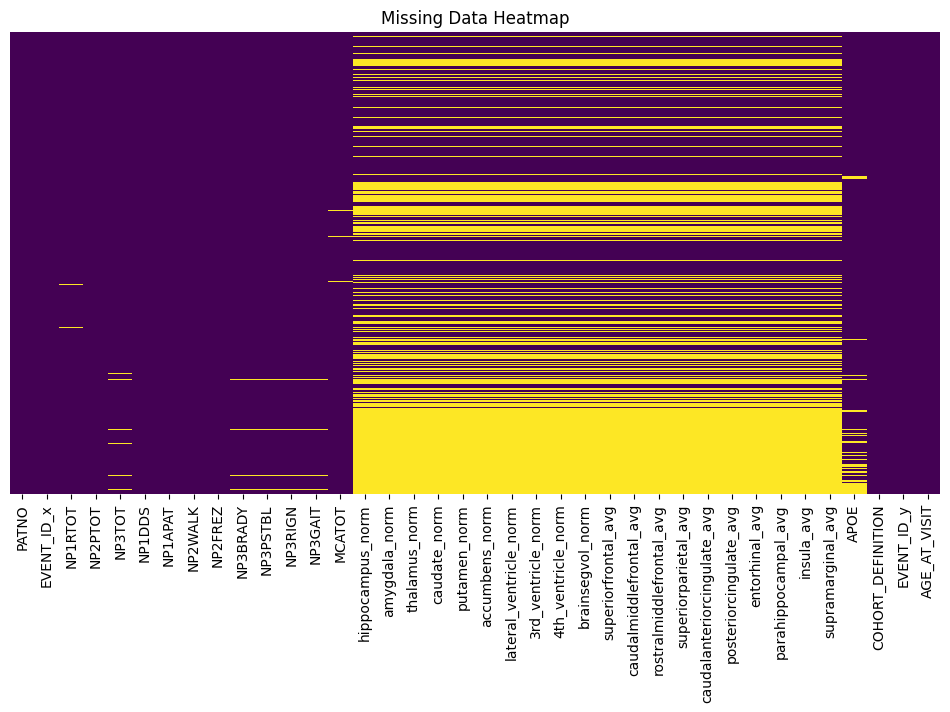

In [ ]:
# Check total missing values per column
missing_values = baseline_df3.isnull().sum()

# Check percentage of missing values per column
missing_percentage = (baseline_df3.isnull().mean() * 100).round(2)

# Combine into a DataFrame for better visualization
missing_summary = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage (%)': missing_percentage
})

# Display columns with missing values (optional: filter to show only columns with missing data)
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(by='Missing_Percentage (%)', ascending=False)

print("Missing Values Summary:")
print(missing_summary)

# Optional: Visualize missingness (requires matplotlib & seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(baseline_df3.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()